# Volcano Plot for Olink Baseline Comparison: ARI|HC1

In [1]:
quiet_library <- function(...){
    suppressPackageStartupMessages(library(...))
}

In [2]:
quiet_library(hise)
quiet_library(dplyr)
quiet_library(ggplot2)
quiet_library(ggrepel)

## Read in Aim 1 HC1|ARI differential proteins

In [3]:
# from IDE for ALTRA Olink Results Aim 1: CON | ARI 2024-10-22

ari_dap_uuid <- '2455b335-7f8f-4839-9145-752cabfe319c' # zahin-totok-popin/2024-10-22_Risk_lm_riskVariable.csv

In [4]:
ari_dap_file <- cacheFiles(list(ari_dap_uuid))

ari_dap <- read.csv(ari_dap_file, 
                header = T, 
                stringsAsFactors = F)

nrow(ari_dap)

[1] "downloading fileID 2455b335-7f8f-4839-9145-752cabfe319c"


[1] 1327

## Visualization: Volcano Plot

In [5]:
# identify cytokines and chemokines
pattern <- c('CCL', 'CXCL', 'CCR', 'CXCR', 'IL')

In [6]:
cyto <- ari_dap %>%
    filter(grepl(paste0(pattern, collapse = '|'), Assay),
           qval <= 0.1)

nrow(cyto)

[1] 23

In [7]:
# refine for display

cyto2 <- cyto %>%
    filter(Estimate > 0.38, 
           qval < 0.06)

In [8]:
# generate final list of proteins to display

poi <- ari_dap %>%
    slice_min(qval, n = 20) %>%
    bind_rows(cyto2) %>%
    distinct(OlinkID, .keep_all = T)

nrow(poi)

[1] 25

In [9]:
plotVolcano <- function(df, poi, p) {

    ggplot(df, aes(x=Estimate,
                   y=-log10(qval), 
                   colour=ifelse(OlinkID %in% poi$OlinkID, 
                                 'Label', 
                                 pcat), 
                   label = ifelse(OlinkID %in% poi$OlinkID, 
                                  Assay, 
                                  ''))) + 
        geom_point() + 
        geom_text_repel(size = 5, 
                        min.segment.length = unit(0, 'lines'), 
                        max.overlaps = Inf, 
                        box.padding = 0.55) +
        scale_colour_manual(values = c('#4C8CBD',
                                       'orangered4',
                                       'black', 
                                       '#F59F00')) +  
        geom_hline(yintercept = -log10(p), 
                   linetype = 'dashed') + 
        labs(x='log2 Effect Size', 
             y='-log10 (q-value)') + 
        theme_classic() + 
        theme (plot.title = element_text(size=12, face='bold', hjust=0.5), 
               legend.position = 'none',
               axis.text.y = element_text(size = 12),
               axis.text.x = element_text(size = 12), 
               axis.title.y = element_text(size = 12), 
               axis.title.x = element_text(size = 12))

}

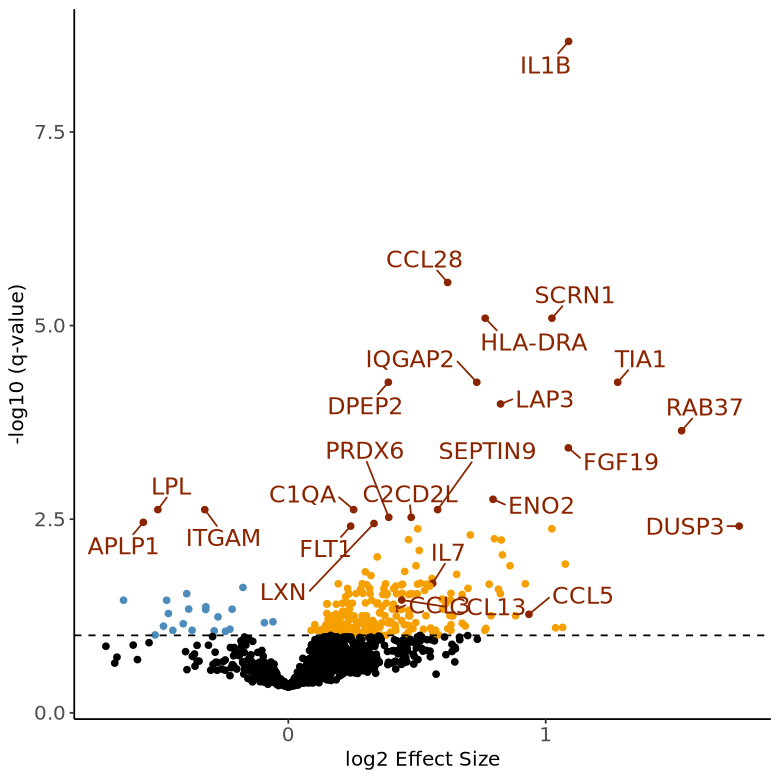

In [10]:
options(repr.plot.width = 6.5, repr.plot.height = 6.5)

p <- plotVolcano(ari_dap, poi, 0.1)

print(p)

In [11]:
ggsave(filename = 'Olink_Volcano_ARIvsCON1.pdf', 
       path = 'Figures',
       p,
       device = 'pdf', 
       width = 6, 
       height = 6, 
       units = 'in')

In [12]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/olink/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] ggrepel_0.9.5 ggplot2_3.5.1 dplyr_1.1.4   hise_2.16.0  

loaded via a namespace (and not attached):
 [1] gtable_0.3.5      jsonlite_1.8.8    compiler_4.3.3    crayon_1.5.3     
 [5] tidyselect_1.2.1  Rcpp_1.0.13       IRdisplay_1.1     bitops_1.0-8     
 [9] assertthat_0.2.1  textshaping_0.4.0 systemfonts_1.1